In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
from utils.enums import Ticker, TimeFrame, Direction
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from feature_extraction.feature_extractor_class import FeatureExtractor
from feature_selection.base_models import BaseModel, QuantileBinningModel
from ensemble.vault_manager import (
    initialize_vault, create_ensemble_directory, 
    load_feature_base_models, list_features
)
from eda.feature_explorer import FeatureExplorer
import utils.helpers as helpers

/home/raman/repos/Trading-Algo/utils/permutation_test/permute_bars.py:38: UserWarning: feature_selection.opt_thresh not found. Using simplified threshold optimization. For full functionality, ensure the opt_thresh module is available.
  warnings.warn(


# Buy and Hold Bias Node - Vault Integration Test

This notebook demonstrates:
1. Extracting the buy_hold feature (always outputs 1.0)
2. Visualizing the feature and comparing with returns
3. Creating a BaseModel with binning
4. Saving to vault as an end-to-end integration test

In [3]:
# Step 1: Extract buy_hold feature
extractor = FeatureExtractor(
    tickers=[Ticker.ES],
    start=datetime(2020, 1, 1),
    end=datetime(2024, 12, 31)
)

bias_node_specs = [{
    'module_name': 'buy_hold',
    'timeframes': [TimeFrame.D],
    'params': {}
}]

result = extractor.extract(bias_node_specs=bias_node_specs)
features = result['features']
targets = result['targets']

print(f"Features shape: {features.shape}")
print(f"Targets shape: {targets.shape}")
print(f"\nFeature columns: {list(features.columns)}")
print(f"\nFirst few feature values:")
print(features.head())


FeatureExtractor Initialized
Tickers: ['ES']
Date range: 2020-01-01 to 2024-12-31
Multi-ticker offset: True


Starting Feature Extraction
Bias nodes: 1

Extracting 1 bias node(s) in a single backtest...
⚠ Cython node optimizations not available (compile with: python utils/setup_cython.py build_ext --inplace)


Running backtest features:   0%|          | 0/1260 [00:00<?, ?candles/s]/home/raman/repos/Trading-Algo/feature_extraction/ml_manager.py:130: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
/home/raman/repos/Trading-Algo/feature_extraction/ml_manager.py:130: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
Running backtest features: 100%|██████████| 1260/1260 [00:00<00:00, 8260.18candles/s]


✓ Extracted 5 features in single backtest

Combining all modules...
Generating feature metadata by parsing column names
✓ Combined features: 1 feature columns
✓ Normalization columns: 4 (ATR/EWSD)
✓ Date range: 2020-01-02 00:00:00+00:00 to 2024-12-31 00:00:00+00:00
✓ Samples: 1260

Features shape: (1260, 2)
Targets shape: (1260, 5)

Feature columns: ['buy_hold_signal_D', 'ticker']

First few feature values:
                           buy_hold_signal_D ticker
2020-01-02 00:00:00+00:00                0.0     ES
2020-01-03 00:00:00+00:00                1.0     ES
2020-01-06 00:00:00+00:00                1.0     ES
2020-01-07 00:00:00+00:00                1.0     ES
2020-01-08 00:00:00+00:00                1.0     ES


/home/raman/repos/Trading-Algo/metrics/plotting/distribution.py:96: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(p1 - margin, p99 + margin)


FeatureExplorer created successfully!
  Number of features: 1
  Feature names: ['buy_hold_signal_D']
  Number of samples: 1260

Plotting distributions for 1 features

[1/1] buy_hold_signal_D
  ✓ Complete

Completed 1/1 features


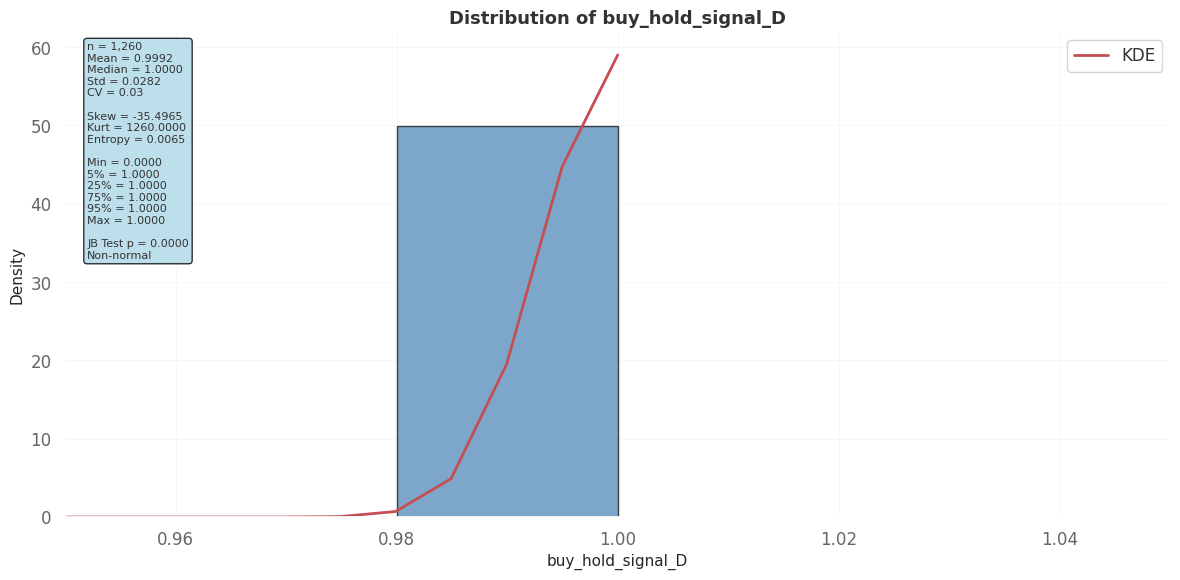


Plotting time series for 1 features

[1/1] buy_hold_signal_D
  ✓ Complete

Completed 1/1 features


/home/raman/repos/Trading-Algo/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/raman/repos/Trading-Algo/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


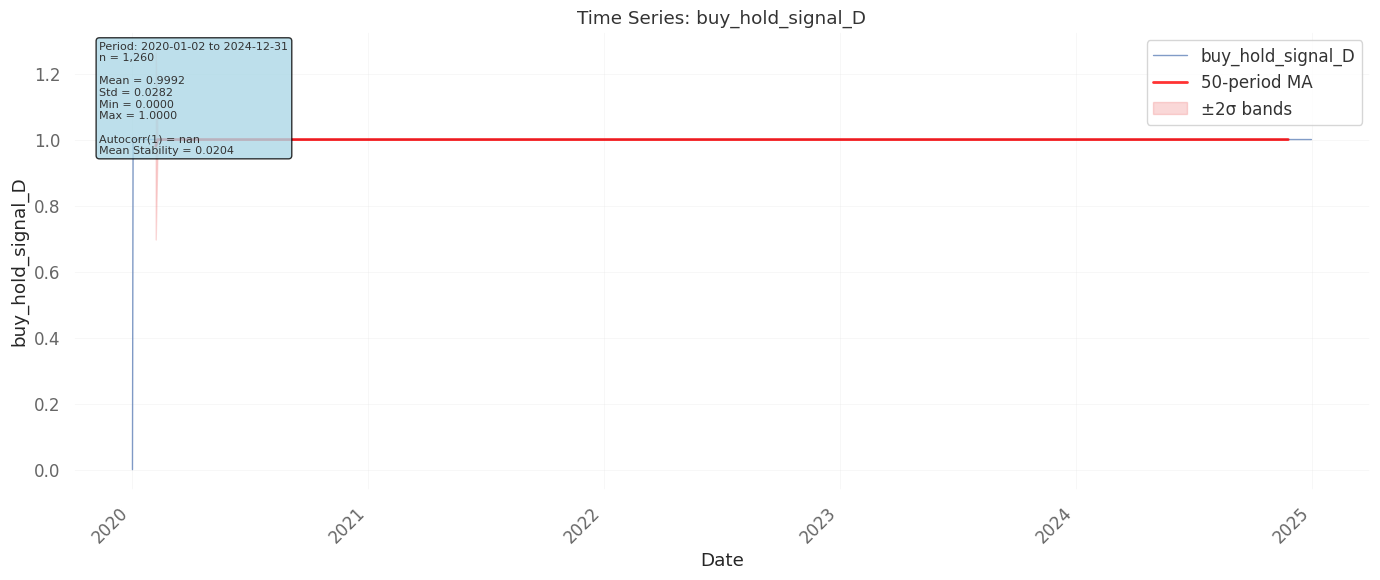


Plotting decile analysis for 1 features
Target: log_return

[1/1] buy_hold_signal_D
  ✓ Complete

Completed 1/1 features


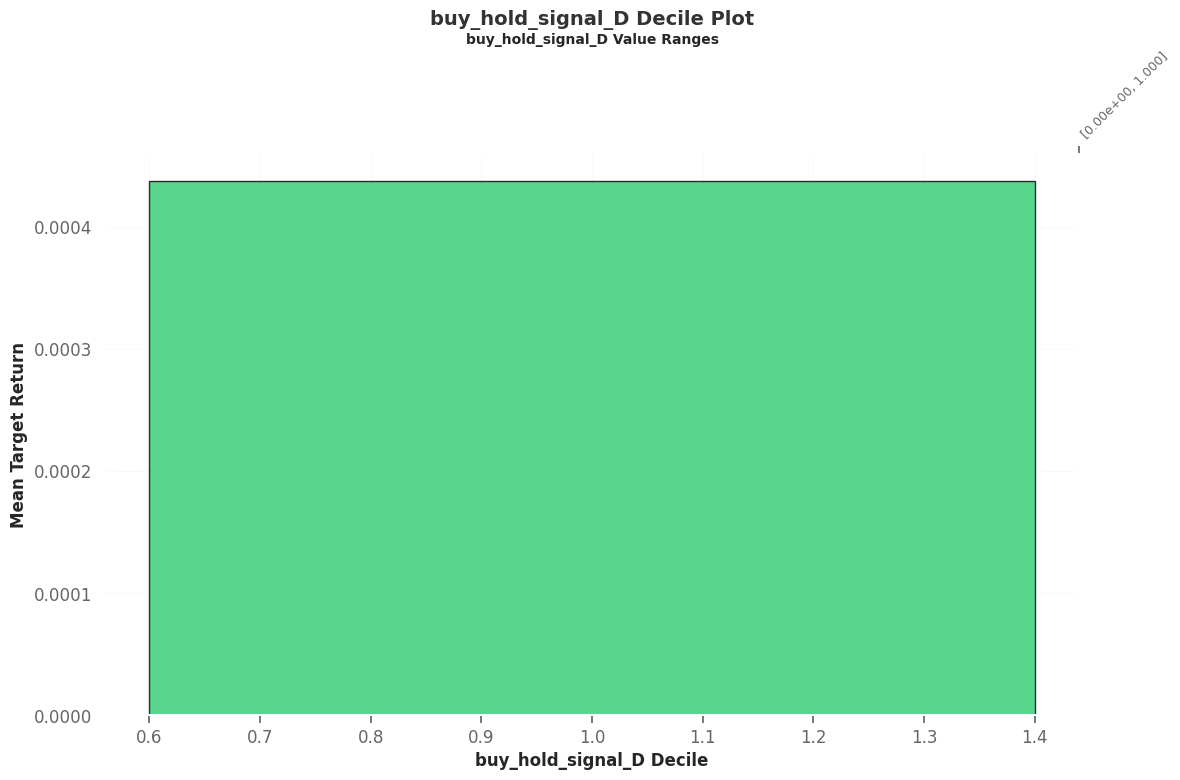


Feature statistics for buy_hold_signal_D:
  Min: 0.0
  Max: 1.0
  Mean: 0.9992063492063492
  Unique values: 2
  All values == 1.0: False


In [4]:
# Step 2: Create FeatureExplorer and visualize
explorer = FeatureExplorer(
    features_df=features,
    targets_df=targets,
    metadata=result
)

print("FeatureExplorer created successfully!")
print(f"  Number of features: {explorer.n_features}")
print(f"  Feature names: {explorer.feature_names}")
print(f"  Number of samples: {explorer.n_samples}")

# Plot distributions and timeseries
explorer.plot_distributions(bins=50)
plt.show()

explorer.plot_timeseries(rolling_window=50)
plt.show()

# Plot decile analysis
figs = explorer.plot_all_deciles(n_bins=4, target_col='log_return')
plt.show()

# Verify feature is constant (buy_hold should always be 1.0)
feature_col = explorer.feature_names[0]  # Should be buy_hold_signal_D
feature_series = features[feature_col]
print(f"\nFeature statistics for {feature_col}:")
print(f"  Min: {feature_series.min()}")
print(f"  Max: {feature_series.max()}")
print(f"  Mean: {feature_series.mean()}")
print(f"  Unique values: {feature_series.nunique()}")
print(f"  All values == 1.0: {(feature_series == 1.0).all()}")

In [ ]:
# Step 3: Load candles data for BaseModel.fit()
# BaseModel.fit() requires candles_df with columns: datetime, open, high, low, close, volume, ticker, timeframe
candles_df = helpers.load_data(
    ticker=Ticker.ES,
    timeframe=TimeFrame.D,
    start=datetime(2020, 1, 1),
    end=datetime(2024, 12, 31)
)

# Reset index to get datetime as column
candles_df = candles_df.reset_index()
candles_df['ticker'] = Ticker.ES
candles_df['timeframe'] = TimeFrame.D

# Align with features index (in case of any filtering)
candles_df = candles_df[candles_df['datetime'].isin(features.index)]
candles_df = candles_df.sort_values('datetime').reset_index(drop=True)

print(f"Candles shape: {candles_df.shape}")
print(f"Candles columns: {list(candles_df.columns)}")
print(f"\nFirst few candles:")
print(candles_df.head())

In [ ]:
# Step 4: Create and fit BaseModel
# Use n_bins=2 (minimum that works with binning logic)
# Since buy_hold always outputs 1.0, it will be a constant feature
binning_model = QuantileBinningModel(n_bins=2, selection_metric='sortino', strategy='long')

bias_spec = {
    'module_name': 'buy_hold',
    'timeframes': [TimeFrame.D],
    'params': {}
}

base_model = BaseModel(
    bias_node_spec=bias_spec,
    binning_model=binning_model,
    ticker=Ticker.ES
)

# Prepare target data aligned with candles
target_series = targets['log_return'].reindex(candles_df['datetime']).dropna()

# Fit model
print("Fitting BaseModel...")
base_model.fit(candles_df, target_series)
print(f"✓ Model fitted successfully!")
print(f"  Feature column: {base_model.feature_column}")
print(f"  Binning model fitted: {base_model.binning_model.is_fitted_}")
print(f"  Best long bin: {base_model.binning_model.best_long_bin_}")
print(f"  Thresholds: {base_model.binning_model.thresholds_}")

# Visualize signal performance using FeatureExplorer
from metrics.performance import SortinoRatio
metric = SortinoRatio(annualization_factor=252)

figs, summary = explorer.plot_signal_cumsum(
    target_col='log_return',
    base_model=base_model,
    show_plot=True,
    metric=metric,
    strategy='long'
)
plt.show()

print("\nSignal Performance Summary:")
print(summary)

In [ ]:
# Step 5: Test predictions (should always be 1 for buy and hold)
test_candles = candles_df.tail(100)  # Last 100 candles
predictions = base_model.predict(test_candles, strategy='long')

print(f"Predictions shape: {predictions.shape}")
print(f"Unique prediction values: {np.unique(predictions)}")
print(f"All predictions == 1: {(predictions == 1).all()}")
print(f"\nFirst 10 predictions:")
print(predictions.head(10))

In [ ]:
# Step 6: Save to vault
print("Initializing vault...")
initialize_vault('vault')

print("Creating ensemble directory...")
ensemble_dir = create_ensemble_directory(
    vault_root='vault',
    timeframe=TimeFrame.D,
    ensemble_name='buy_hold',
    direction=Direction.LONG
)
print(f"✓ Created ensemble directory: {ensemble_dir}")

print("\nSaving base model to vault...")
model_id = base_model.save_to_vault(ensemble_dir)
print(f"✓ Saved model with ID: {model_id}")
print(f"  Feature column: {base_model.feature_column}")
print(f"  Model ID: {model_id}")

In [ ]:
# Step 7: Verify vault save/load
print("Loading models from vault...")
loaded_models = load_feature_base_models(
    ensemble_dir=ensemble_dir,
    feature_column=base_model.feature_column,
    ticker=Ticker.ES
)

print(f"✓ Loaded {len(loaded_models)} model(s)")
print(f"  Model IDs: {list(loaded_models.keys())}")

# Verify loaded model
if model_id in loaded_models:
    loaded_model = loaded_models[model_id]
    print(f"\n✓ Model '{model_id}' loaded successfully")
    print(f"  Binning model fitted: {loaded_model.binning_model.is_fitted_}")
    print(f"  Best long bin: {loaded_model.binning_model.best_long_bin_}")
    
    # Test predictions with loaded model
    test_predictions = loaded_model.predict(test_candles, strategy='long')
    print(f"  Predictions from loaded model all == 1: {(test_predictions == 1).all()}")

# List all features in ensemble
print("\n" + "="*70)
print("Features in ensemble:")
print("="*70)
features_df = list_features(ensemble_dir)
print(features_df)